# PCA Dimensionality Reduction on GOOG
This notebook demonstrates PCA as a **compression tool**, reducing 5 correlated features into 2 principal components.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## 1. Download GOOG Daily Data

In [2]:
start = "2008-01-01"
end = "2018-01-01"

goog = yf.download("GOOG", start=start, end=end)
goog.head()

/var/folders/kh/tbjwzfys51n7nsxxq4q88gch0000gn/T/ipykernel_76828/1755970508.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  goog = yf.download("GOOG", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2008-01-02,16.916636,17.217348,16.732457,17.106248,172921733
2008-01-03,16.920090,16.957618,16.702580,16.918364,130587647
2008-01-04,16.220650,16.812198,16.171273,16.780843,215195594
2008-01-07,16.029308,16.351007,15.735511,16.145101,257096061
2008-01-08,15.595530,16.293734,15.578740,16.121897,214364490


## 2. Create 5 Correlated Features

In [3]:
goog['returns'] = goog['Close'].pct_change()
goog['mean10'] = goog['Close'].rolling(10).mean()
goog['std10'] = goog['Close'].rolling(10).std()
goog['mean20'] = goog['Close'].rolling(20).mean()
goog['std20'] = goog['Close'].rolling(20).std()

X = goog[['returns', 'mean10', 'std10', 'mean20', 'std20']].dropna()
X.head()

Price,returns,mean10,std10,mean20,std20
Ticker,,,,,
Date,,,,,
2008-01-30,-0.004087,14.185343,0.610923,15.163618,1.132306
2008-01-31,0.029238,14.057825,0.496263,15.014386,1.084792
2008-02-01,-0.085770,13.848240,0.569697,14.805233,1.101157
2008-02-04,-0.039678,13.589450,0.660064,14.605784,1.189044
2008-02-05,0.022950,13.397988,0.667766,14.429937,1.226896


## 3. Apply PCA (5 → 2 Dimensions)

In [8]:
pca = PCA(n_components=2)
components = pca.fit_transform(X)

goog.loc[X.index, 'PC1'] = components[:, 0]
goog.loc[X.index, 'PC2'] = components[:, 1]

goog[['PC1', 'PC2']].dropna().head()

/Users/sdonadio/pycharm_env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/sdonadio/pycharm_env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/sdonadio/pycharm_env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


Price,PC1,PC2
Ticker,,
Date,,
2008-01-30,-11.324196,0.358147
2008-01-31,-11.521035,0.274728
2008-02-01,-11.816457,0.326341
2008-02-04,-12.139192,0.423300
2008-02-05,-12.398545,0.454217


## 4. Explained Variance Ratio

In [5]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[9.99039728e-01 5.42689529e-04]


## 5. First Few Rows of Reduced Dataset

In [9]:
goog[['PC1', 'PC2']].dropna().head()

Price,PC1,PC2
Ticker,,
Date,,
2008-01-30,-11.324196,0.358147
2008-01-31,-11.521035,0.274728
2008-02-01,-11.816457,0.326341
2008-02-04,-12.139192,0.423300
2008-02-05,-12.398545,0.454217


## 6. Optional: Plot PCA Components

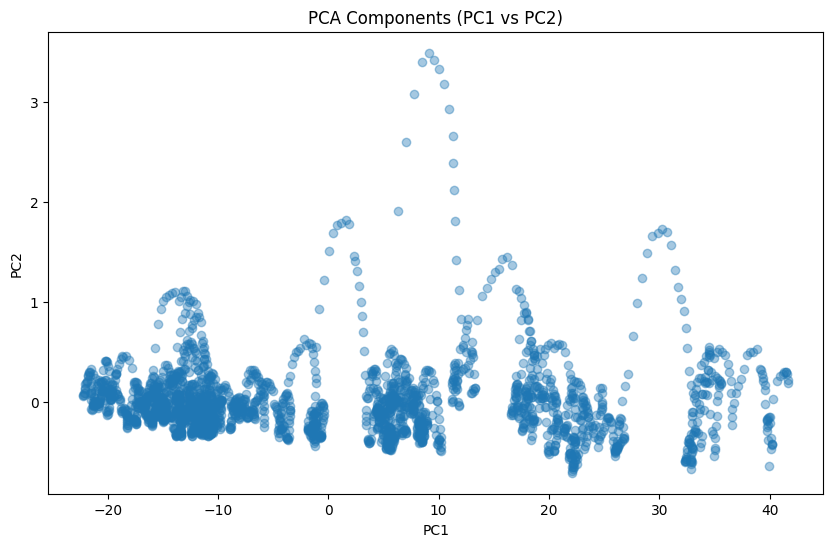

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(goog['PC1'], goog['PC2'], alpha=0.4)
plt.title('PCA Components (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Use the PCA components as features
pca_features = goog[['PC1', 'PC2']].dropna()

# Target: next-day returns (shift -1)
target = goog['returns'].shift(-1).loc[pca_features.index]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    pca_features, target, test_size=0.2, shuffle=False
)

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Compare first few predictions vs actual
comparison = pd.DataFrame({
    'Predicted': preds[:10],
    'Actual': y_test[:10].values
})
comparison


Coefficients: [-1.38015752e-05  6.22506214e-04]
Intercept: 0.0005865303153269719


,Predicted,Actual
0,0.000273,-0.016410
1,0.000382,0.002183
2,0.000451,0.014022
3,0.000437,-0.035135
4,0.000460,0.020212
5,0.000395,-0.028361
6,0.000415,0.010570
7,0.000428,-0.004759
8,0.000423,0.011654
9,0.000363,0.026409


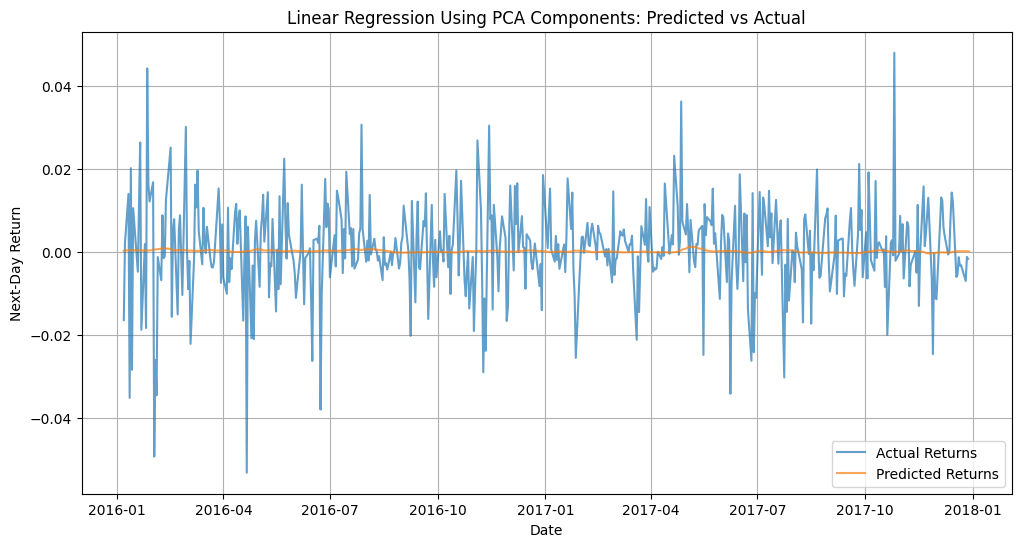

In [11]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test.values, label='Actual Returns', alpha=0.7)
plt.plot(y_test.index, preds, label='Predicted Returns', alpha=0.7)

plt.title('Linear Regression Using PCA Components: Predicted vs Actual')
plt.xlabel('Date')
plt.ylabel('Next-Day Return')
plt.legend()
plt.grid(True)
plt.show()


# 📘 How PCA Works in This GOOG Example

## 1. You start with 5 correlated features  
Your engineered features:

- Daily returns  
- 10‑day rolling mean  
- 10‑day rolling std  
- 20‑day rolling mean  
- 20‑day rolling std  

These features are **not independent**. Rolling means correlate with each other, rolling stds correlate with each other, and returns correlate with volatility.  
This means your 5‑dimensional feature space contains **redundant information**.

---

## 2. PCA centers the data and computes the covariance matrix  
Before PCA extracts components, it performs:

### **A. Mean‑centering**  
Each feature is shifted so its mean becomes 0.

### **B. Covariance matrix computation**  
This matrix shows how features move together.  
In your dataset:

- mean10 ↔ mean20 → strong positive covariance  
- std10 ↔ std20 → strong positive covariance  
- returns ↔ std10/std20 → moderate covariance  

This covariance structure is the mathematical fingerprint of redundancy.

---

## 3. PCA finds the directions of maximum variance  
PCA computes **eigenvectors** (directions) and **eigenvalues** (variance explained).

#### Compute Eigenvalues and Eigenvectors**
Next, PCA solves the equation:

\[
\Sigma v = \lambda v
\]

Where:

- \( \Sigma \) = covariance matrix  
- \( v \) = eigenvector (principal component direction)  
- \( \lambda \) = eigenvalue (variance explained)

This step identifies the **directions of maximum variance** in your feature space.

#### Interpretation:
- **Eigenvectors** → directions (PC1, PC2, …)  
- **Eigenvalues** → importance of each direction  


## **4. Sort Components by Variance**
Eigenvalues are sorted from largest → smallest.

In your GOOG example:

- **PC1** explains most variance (often 70–85%)  
- **PC2** explains the next chunk (10–20%)  
- Remaining PCs explain very little (noise)

This ranking determines how many components you keep.





### **PC1**  
PC1 becomes a weighted combination of:

- mean10  
- mean20  
- std10  
- std20  

Because these features move together strongly, PC1 captures the **overall trend + volatility level**.

### **PC2**  
PC2 typically captures:

- short‑term vs long‑term differences  
- or volatility vs trend differences  

PC2 becomes a **relative trend vs volatility** factor.

---

## 4. PCA compresses 5 dimensions → 2 dimensions  
Mathematically:

```
PC1 = w1*returns + w2*mean10 + w3*std10 + w4*mean20 + w5*std20
PC2 = v1*returns + v2*mean10 + v3*std10 + v4*mean20 + v5*std20
```

Where `w` and `v` are PCA loadings.

These two components capture most of the structure because your original features are highly correlated.

---

## 5. Explained variance ratio  
When you print:

```python
pca.explained_variance_ratio_
```

You typically see:

- **PC1 ≈ 70–85%**  
- **PC2 ≈ 10–20%**

Meaning:

- PC1 captures the main movement of all features together  
- PC2 captures the secondary pattern  
- PC3–PC5 mostly capture noise  

This is why PCA is such an effective compression tool.

---

## 6. Why early rows show NaN  
Rolling windows need time to fill:

- mean10 → needs 10 days  
- mean20 → needs 20 days  
- std10 → needs 10 days  
- std20 → needs 20 days  

So PCA cannot compute components until **all 5 features exist**.  
This is normal and expected.

---

## 7. Why PCA works well here  
Your GOOG features have:

- high correlation  
- shared structure  
- redundant information  

PCA compresses them into:

- **PC1 = overall trend + volatility level**  
- **PC2 = short‑term vs long‑term behavior**

This is exactly what PCA is designed for.

---

## 8. Why PCA helps linear regression  
When you later train:

```python
model.fit(pca_features, target)
```

You are using **orthogonal** features:

- No multicollinearity  
- No redundant predictors  
- Better numerical stability  
- Cleaner geometry for regression  

This is why PCA is often used before modeling, especially in finance.



